In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time

import jax
import jax.numpy as jnp

import importlib, os
import east

In [2]:
importlib.reload(east)

key       = jax.random.PRNGKey(7)
N         = 1024
n_walkers = 512

window = {
    3:  dict(dt_record=0.125,    n_records=200),  # max_t=25
    4:  dict(dt_record=0.5,      n_records=200),  # max_t=100
    6:  dict(dt_record=4.0,      n_records=150),  # max_t=600
    8:  dict(dt_record=25.0,     n_records=150),  # max_t=3750
    10: dict(dt_record=120.0,    n_records=100),  # max_t=12000
    12: dict(dt_record=400.0,    n_records=90),   # max_t=36000
    14: dict(dt_record=3000.0,   n_records=45),   # max_t=135000
    16: dict(dt_record=5000.0,   n_records=36),   # max_t=180000
}

window = {
    3:  dict(dt_record=0.25,     n_records=100),  # max_t=25
    4:  dict(dt_record=1,        n_records=100),  # max_t=100
    6:  dict(dt_record=6.0,      n_records=100),  # max_t=600
    8:  dict(dt_record=37.5,     n_records=100),  # max_t=3750
    10: dict(dt_record=120.0,    n_records=100),  # max_t=12000
    12: dict(dt_record=360.0,    n_records=100),   # max_t=36000
    14: dict(dt_record=1350.0,   n_records=100),   # max_t=135000
    16: dict(dt_record=1800.0,   n_records=100),   # max_t=180000
}

ls = list(window.keys())

In [3]:
def iso_relaxation_time(times, mean_traj, state_init, c_eq):
    """
    Compute tau_iso from the 1/e crossing of the group-mean propensity curves.

    For initially-up sites:   find when mean_up(t)  first drops to c_eq + (1-c_eq)/e.
    For initially-down sites: find when mean_dn(t)  first rises to c_eq - c_eq/e.

    tau_iso is the weighted average of tau_up and tau_dn, weighted by group size.
    Returns (tau_iso, tau_up, tau_dn).
    """
    def _crossing(traj_1d, threshold, from_above):
        crossed = traj_1d <= threshold if from_above else traj_1d >= threshold
        if not np.any(crossed[1:]):
            return np.nan
        idx = int(np.argmax(crossed[1:])) + 1
        t1, t2 = times[idx - 1], times[idx]
        v1, v2 = traj_1d[idx - 1], traj_1d[idx]
        dv = v2 - v1
        if abs(dv) < 1e-15:
            return float(times[idx])
        return t1 + (threshold - v1) * (t2 - t1) / dv

    up_mask = state_init == 1
    dn_mask = state_init == 0
    n_up = int(up_mask.sum())
    n_dn = int(dn_mask.sum())

    tau_up = np.nan
    if n_up > 0:
        mean_up = mean_traj[:, up_mask].mean(axis=1)
        tau_up  = _crossing(mean_up, c_eq + (1 - c_eq) / np.e, from_above=True)

    tau_dn = np.nan
    if n_dn > 0:
        mean_dn = mean_traj[:, dn_mask].mean(axis=1)
        tau_dn  = _crossing(mean_dn, c_eq - c_eq / np.e, from_above=False)

    taus    = np.array([tau_up, tau_dn])
    weights = np.array([n_up,   n_dn],   dtype=float)
    valid   = ~np.isnan(taus)
    tau_iso = float(np.average(taus[valid], weights=weights[valid])) if valid.any() else np.nan

    return tau_iso, tau_up, tau_dn

In [4]:
if os.path.exists('iso_results.npy'):
    iso_results = np.load('iso_results.npy', allow_pickle=True).item()
    print('Loaded iso_results.npy')
    for l in ls:
        r = iso_results[l]
        print(f"l={l:2d}  T={r['T']:.4f}  "
              f"tau_iso={r['tau_iso']:10.1f}  "
              f"tau_up={r.get('tau_up', float('nan')):10.1f}  "
              f"tau_dn={r.get('tau_dn', float('nan')):10.1f}  "
              f"max_t={r['times'][-1]:.1f}")
else:
    iso_results = {}
    for l in ls:
        T    = float(east.temperature_from_length(l))
        c_eq = float(east.concentration(T))
        p    = window[l]

        key, init_key, run_key = jax.random.split(key, 3)

        # fix the number of excitations to exactly round(N * c_eq) so that
        # concentration fluctuations in a single sampled config don't bias tau_iso
        n_up = int(round(N * c_eq))
        state_init = jax.random.permutation(
            init_key,
            jnp.concatenate([jnp.ones(n_up, dtype=jnp.int32),
                              jnp.zeros(N - n_up, dtype=jnp.int32)])
        )

        t0 = time.time()
        mean_traj, _ = east.isoconfigurational_ensemble(
            N, T, p['dt_record'], p['n_records'], n_walkers, state_init, run_key
        )
        mean_traj_np  = np.array(mean_traj)   # forces JAX to finish computing
        wall_time = time.time() - t0

        times         = np.arange(p['n_records'] + 1, dtype=float) * p['dt_record']
        state_init_np = np.array(state_init)

        tau_iso, tau_up, tau_dn = iso_relaxation_time(
            times, mean_traj_np, state_init_np, c_eq
        )

        iso_results[l] = dict(
            T=T, c_eq=c_eq,
            times=times,
            mean_traj=mean_traj_np,
            state_init=state_init_np,
            tau_iso=tau_iso,
            tau_up=tau_up,
            tau_dn=tau_dn,
        )
        actual_c = state_init_np.mean()
        print(f"l={l:2d}  T={T:.4f}  c_eq={c_eq:.4f}  actual_c={actual_c:.4f}  "
              f"tau_iso={tau_iso:10.1f}  "
              f"tau_up={tau_up:10.1f}  tau_dn={tau_dn:10.1f}  "
              f"max_t={float(times[-1]):.1f}  "
              f"wall={wall_time:.1f}s")

l= 3  T=1.4427  c_eq=0.3333  actual_c=0.3330  tau_iso=      10.1  tau_up=      11.7  tau_dn=       9.3  max_t=25.0  wall=20.3s
l= 4  T=0.9102  c_eq=0.2500  actual_c=0.2500  tau_iso=      41.1  tau_up=      44.5  tau_dn=      40.0  max_t=100.0  wall=42.7s
l= 6  T=0.6213  c_eq=0.1667  actual_c=0.1670  tau_iso=     334.9  tau_up=     318.0  tau_dn=     338.2  max_t=600.0  wall=110.1s
l= 8  T=0.5139  c_eq=0.1250  actual_c=0.1250  tau_iso=    1631.0  tau_up=    1701.5  tau_dn=    1620.9  max_t=3750.0  wall=398.7s
l=10  T=0.4551  c_eq=0.1000  actual_c=0.0996  tau_iso=    5146.8  tau_up=    7279.2  tau_dn=    4910.8  max_t=12000.0  wall=807.1s
l=12  T=0.4170  c_eq=0.0833  actual_c=0.0830  tau_iso=   16506.9  tau_up=   21376.9  tau_dn=   16066.1  max_t=36000.0  wall=1686.5s
l=14  T=0.3899  c_eq=0.0714  actual_c=0.0713  tau_iso=   52069.1  tau_up=   61713.9  tau_dn=   51328.8  max_t=135000.0  wall=4625.5s
l=16  T=0.3693  c_eq=0.0625  actual_c=0.0625  tau_iso=  126757.6  tau_up=  151435.8  tau_d

In [5]:
for l in ls:

    sampled_conc = iso_results[l]['state_init'].mean()
    target_conc = east.concentration(east.temperature_from_length(l))
    
    print("l = {}".format(l))
    print("Sampled: {:.4f}\t\tTarget: {:.4f}".format(sampled_conc, target_conc))
    print()

l = 3
Sampled: 0.3330		Target: 0.3333

l = 4
Sampled: 0.2500		Target: 0.2500

l = 6
Sampled: 0.1670		Target: 0.1667

l = 8
Sampled: 0.1250		Target: 0.1250

l = 10
Sampled: 0.0996		Target: 0.1000

l = 12
Sampled: 0.0830		Target: 0.0833

l = 14
Sampled: 0.0713		Target: 0.0714

l = 16
Sampled: 0.0625		Target: 0.0625



## Decay plots

Each thin line is the isoconfigurational average propensity $\langle s_i(t) \rangle$ for a single site, coloured by initial state (red = initially up, blue = initially down). Bold lines show the group mean. All curves decay toward $c_{\rm eq}$ (dashed grey).

The grey shaded band is the convergence zone $[c_{\rm eq} - c_{\rm eq}/e,\; c_{\rm eq} + (1-c_{\rm eq})/e]$. The dashed green line marks $\tau_{\rm iso}$, defined as the size-weighted average of the times at which the mean up-spin curve and mean down-spin curve first enter this band.

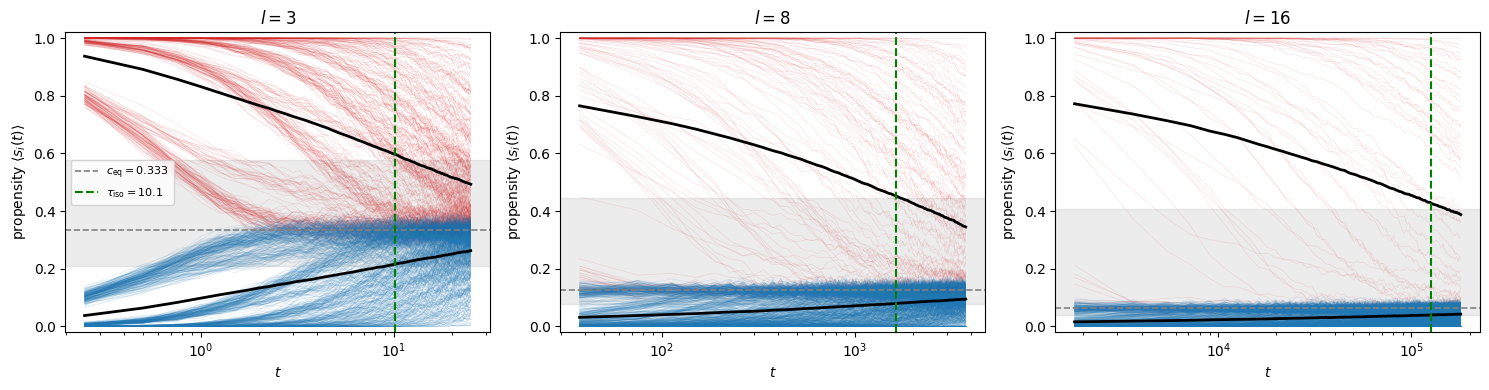

In [8]:
# which ls to show in the decay plots (must be in ls)
ls_plot = [3, 8, 16]

fig, axes = plt.subplots(1, len(ls_plot), figsize=(5 * len(ls_plot), 4),
                         sharex='col')

if len(ls_plot) == 1:
    axes = [axes]

for col, l in enumerate(ls_plot):
    r          = iso_results[l]
    T          = r['T']
    c_eq       = r['c_eq']
    times      = r['times']
    mean_traj  = r['mean_traj']   # shape (T+1, N)
    state_init = r['state_init']
    tau_iso    = r['tau_iso']
    tau_up     = r['tau_up']
    tau_dn     = r['tau_dn']

    up_mask = state_init == 1
    dn_mask = state_init == 0

    # convergence band in raw propensity space
    band_lo = c_eq - c_eq / np.e           # threshold for initially-down sites
    band_hi = c_eq + (1 - c_eq) / np.e    # threshold for initially-up sites

    t_plot = times[1:]   # skip t=0 for log axis

    ax = axes[col]

    # grey convergence band
    ax.axhspan(band_lo, band_hi, color='grey', alpha=0.15, zorder=0)

    # individual site curves
    for i in np.where(up_mask)[0]:
        ax.semilogx(t_plot, mean_traj[1:, i], color='tab:red',  lw=0.4, alpha=0.15)
    for i in np.where(dn_mask)[0]:
        ax.semilogx(t_plot, mean_traj[1:, i], color='tab:blue', lw=0.4, alpha=0.15)

    # bold group means
    ax.semilogx(t_plot, mean_traj[1:][:, up_mask].mean(axis=1),
                color='black',  lw=2.0)
    ax.semilogx(t_plot, mean_traj[1:][:, dn_mask].mean(axis=1),
                color='black', lw=2.0)

    ax.axhline(c_eq, color='gray', ls='--', lw=1.2,
               label=f'$c_{{\\rm eq}}={c_eq:.3f}$')
    if not np.isnan(tau_iso):
        ax.axvline(tau_iso, color='green', ls='--', lw=1.5,
                   label=r'$\tau_{\rm iso}$' + f'$={tau_iso:.1f}$')

    ax.set_xlabel('$t$')
    ax.set_ylabel(r'propensity $\langle s_i(t)\rangle$')
    ax.set_title(f'$l={l}$')
    ax.set_ylim(-0.02, 1.02)
    
axes[0].legend(fontsize=8)

plt.tight_layout()
plt.show()

## Relaxation timescale trend

Left: $\log\tau_{\rm iso}$ vs $1/T$ (Arrhenius).  
Right: $\log\tau_{\rm iso}$ vs $1/T^2$ (Bässler / VTF super-Arrhenius).

ACF timescales from `acf_results.npy` are overlaid for comparison where available.

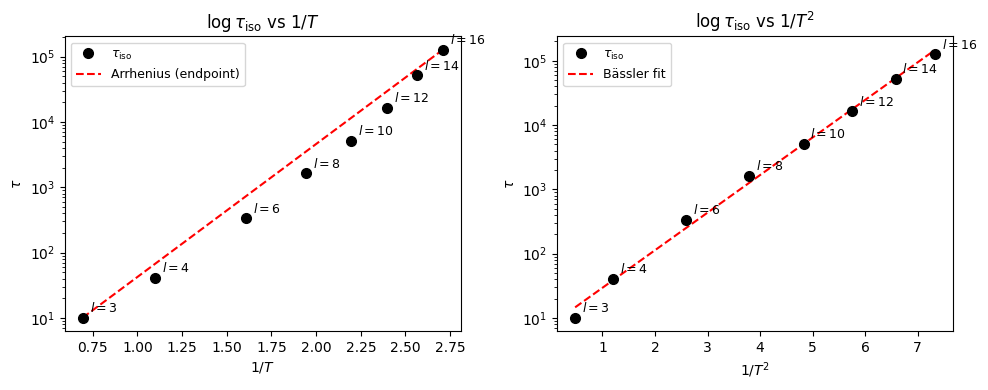

In [9]:
T_arr   = np.array([iso_results[l]['T']       for l in ls])
tau_arr = np.array([iso_results[l]['tau_iso'] for l in ls])
invT    = 1.0 / T_arr
invT2   = invT ** 2
log_tau = np.log(tau_arr)
valid   = ~np.isnan(tau_arr)

# load ACF results for comparison if available
acf_results = None
if os.path.exists('acf_results.npy'):
    acf_results = np.load('acf_results.npy', allow_pickle=True).item()
acf_results = None

# TODO: remove the second `acf_results = None` to plot ACF times with iso times

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, xvals, xlabel, title, two_point in [
    (axes[0], invT,  r'$1/T$',   r'$\log\tau_{\rm iso}$ vs $1/T$',   True),
    (axes[1], invT2, r'$1/T^2$', r'$\log\tau_{\rm iso}$ vs $1/T^2$', False),
]:
    ax.semilogy(xvals[valid], tau_arr[valid], 'ko', ms=7, zorder=3,
                label=r'$\tau_{\rm iso}$')
    for l, x, tau in zip(np.array(ls)[valid], xvals[valid], tau_arr[valid]):
        ax.annotate(f'$l={l}$', (x, tau), textcoords='offset points',
                    xytext=(5, 4), fontsize=9)

    # overlay ACF tau if available
    if acf_results is not None:
        acf_taus   = np.array([acf_results[l]['tau'] for l in ls])
        acf_valid  = ~np.isnan(acf_taus)
        acf_xvals  = xvals  # same T ordering
        ax.semilogy(acf_xvals[acf_valid], acf_taus[acf_valid], 's',
                    color='steelblue', ms=6, zorder=2, alpha=0.7,
                    label=r'$\tau_{\rm ACF}$')

    # fit line
    if two_point:
        x0, x1 = xvals[valid][0], xvals[valid][-1]
        y0, y1 = log_tau[valid][0], log_tau[valid][-1]
        slope  = (y1 - y0) / (x1 - x0)
        coeffs = np.array([slope, y0 - slope * x0])
    else:
        coeffs = np.polyfit(xvals[valid], log_tau[valid], 1)
    x_fit = np.linspace(xvals[valid].min(), xvals[valid].max(), 200)
    fit_label = 'Arrhenius (endpoint)' if two_point else 'Bässler fit'
    ax.semilogy(x_fit, np.exp(np.polyval(coeffs, x_fit)), 'r--', lw=1.5,
                label=fit_label)

    ax.set_xlabel(xlabel)
    ax.set_ylabel(r'$\tau$')
    ax.set_title(title)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

In [10]:
if not os.path.exists('iso_results.npy'):
    np.save('iso_results.npy', iso_results)
    print('Saved iso_results.npy')

Saved iso_results.npy
